In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## (a) Load and examine the license dataset

The goal is to load the license dataset and determine which column uniquely
identifies each elevator. This identifier will be used to track elevators
across multiple datasets in future modules.

In [13]:
df = pd.read_csv("../data/license.csv")

df.head()

,ElevatingDevicesNumber,LocationoftheElevatingDevice,ElevatingDevicesLicenseNumber,LICENSESTATUS,LICENSEEXPIRYDATE,LICENSEHOLDER,LICENSEHOLDERACCOUNTNUMBER,LICENSEHOLDERADDRESS,BILLINGCUSTOMER,BILLINGADDRESS,BILLINGACCOUNT
0,10,111 WELLESLEY ST W TORONTO M7A 1A2 ON CA,EDLIC-000010,ACTIVE,28-Apr-17,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,data redacted,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,data redacted
1,100,1804 HIGHWAY 2 E BROCKVILLE K6V 5T1 ON CA,170719,BY REQUEST,12-Dec-14,INFRASTRUCTURE ONTARIO AND LANDS CORPORATION,data redacted,18 KING ST E TORONTO ON M5C 1C4 CA,CB RICHARD ELLIS GLOBAL CORPORATE SERVICES,333 PRESTON ST 7TH FLR PRESTON SQUARE TOWER 1 ...,data redacted
2,10047,162 PEMBROKE ST W PEMBROKE K8A 5M8 ON CA,EDLIC-010047,BY REQUEST,15-Mar-08,PROFAC MANAGEMENT GROUP LTD,data redacted,304 THE EAST MALL P.O. # 653058-Y3-20610 TORON...,PROFAC MANAGEMENT GROUP LTD,304 THE EAST MALL P.O. # 653058-Y3-20610 TORON...,data redacted
3,10054,541 SUSSEX DR OTTAWA K1N 6Z6 ON CA,EDLIC-010054,BY REQUEST,01-Oct-05,DEPARTMENT OF PUBLIC WORKS & GOVERNMENT SERVIC...,data redacted,4900 YONGE ST 11TH FLOOR TORONTO ON M2N 6A6 CA,DEPARTMENT OF PUBLIC WORKS & GOVERNMENT SERVIC...,"4900 YONGE ST 11TH FLOOR TORONTO, ON, M2N 6A6, CA",data redacted
4,1009,404 MAIN ST WOODSTOCK N4S 7X5 ON CA,EDLIC-001009,ACTIVE,15-Jul-17,AGRIBRANDS PURINA CANADA INC,data redacted,404 MAIN ST PO BOX 250 WOODSTOCK ON N4S 7X5 CA,AGRIBRANDS PURINA CANADA INC,"404 MAIN ST PO BOX 250 WOODSTOCK, ON, N4S 7X5, CA",data redacted


In [14]:
df.columns

Index(['ElevatingDevicesNumber', 'LocationoftheElevatingDevice',
       'ElevatingDevicesLicenseNumber', 'LICENSESTATUS', 'LICENSEEXPIRYDATE',
       'LICENSEHOLDER', 'LICENSEHOLDERACCOUNTNUMBER', 'LICENSEHOLDERADDRESS',
       'BILLINGCUSTOMER', 'BILLINGADDRESS', 'BILLINGACCOUNT'],
      dtype='str')

In [15]:
df["ElevatingDevicesNumber"].nunique(), len(df)

(45383, 45383)

In [16]:
df["ElevatingDevicesLicenseNumber"].nunique(), len(df)

(45383, 45383)

The column **ElevatingDevicesNumber** uniquely identifies each elevator.
The number of distinct values matches the number of rows in the dataset,
indicating a one-to-one relationship.

This makes it a reliable primary identifier for tracking elevators across
datasets such as inspections or installations.

## (b) Extract country and province from the location field

The location column combines address and geographic information.
We extract the country and province/state using string operations.

In [17]:
df["Country"] = df["LocationoftheElevatingDevice"].str.extract(r"\b(CA)\b")
df["Province"] = df["LocationoftheElevatingDevice"].str.extract(r"\b(ON)\b")

df[["Country", "Province"]].value_counts()

Country  Province
CA       ON          45340
Name: count, dtype: int64

The majority of elevators are located in **Ontario (ON), Canada (CA)**.
This matches the dataset’s scope, which covers elevators registered
in the province of Ontario.

## (c) Examine and filter LICENSESTATUS values

We examine the distribution of LICENSESTATUS values and decide which
statuses to keep for a clean working dataset.

In [18]:
df["LICENSESTATUS"].value_counts()

LICENSESTATUS
ACTIVE                   42665
CANCELLED_NOT_RENEWED     1163
PENDING_RENEWAL            632
TERMINATED                 475
BY REQUEST                 337
EXPIRED                     68
HOLD_TSD                    24
TERMINATED DECEASED          6
CANCELLED_BY_CUST_REQ        6
ENTERED                      4
CANCELLED                    3
Name: count, dtype: int64

In [19]:
statuses_to_keep = ["ACTIVE", "BY REQUEST"]

df_filtered = df[df["LICENSESTATUS"].isin(statuses_to_keep)].copy()
df_filtered["LICENSESTATUS"].value_counts()

LICENSESTATUS
ACTIVE        42665
BY REQUEST      337
Name: count, dtype: int64

ACTIVE elevators represent units currently licensed and operational.

BY REQUEST elevators represent valid records pending administrative action
and are still relevant to operations.

Statuses such as CANCELLED_NOT_RENEWED represent decommissioned or
inactive units and are removed to keep a clean operational dataset.

## (d) Verify identifier uniqueness after filtering

In [20]:
df_filtered["ElevatingDevicesNumber"].nunique(), len(df_filtered)

(43002, 43002)

The elevator identifier remains unique after filtering.
This means the filtering operation did not introduce duplication
and the dataset remains safe for future merges with other datasets.

## (e) License expiration timeline analysis

The operations manager wants to understand how license expirations
are distributed over time.

C:\Users\juanjanica\AppData\Local\Temp\ipykernel_20644\218682295.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered["LICENSEEXPIRYDATE"] = pd.to_datetime(df_filtered["LICENSEEXPIRYDATE"])


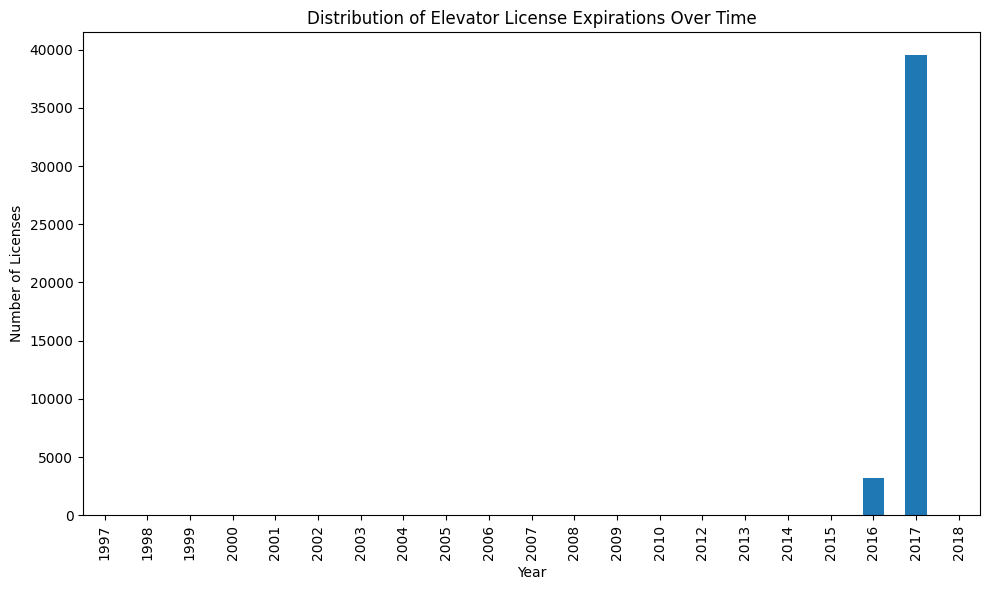

In [21]:
df_filtered["LICENSEEXPIRYDATE"] = pd.to_datetime(df_filtered["LICENSEEXPIRYDATE"])

df_filtered["ExpiryYear"] = df_filtered["LICENSEEXPIRYDATE"].dt.year

expiry_counts = df_filtered["ExpiryYear"].value_counts().sort_index()

plt.figure(figsize=(10,6))
expiry_counts.plot(kind="bar")
plt.title("Distribution of Elevator License Expirations Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Licenses")
plt.tight_layout()
plt.show()

License expirations are concentrated in earlier years,
indicating that the dataset represents a historical snapshot.
This visualization helps differentiate data age from actual
compliance risk.

## Extra-Mile 2 – Two-Column License Status Analysis

The sections above examined LICENSESTATUS and ExpiryYear independently.
Here we combine both columns in a single grouped aggregation to see
how license statuses are distributed across expiry years.

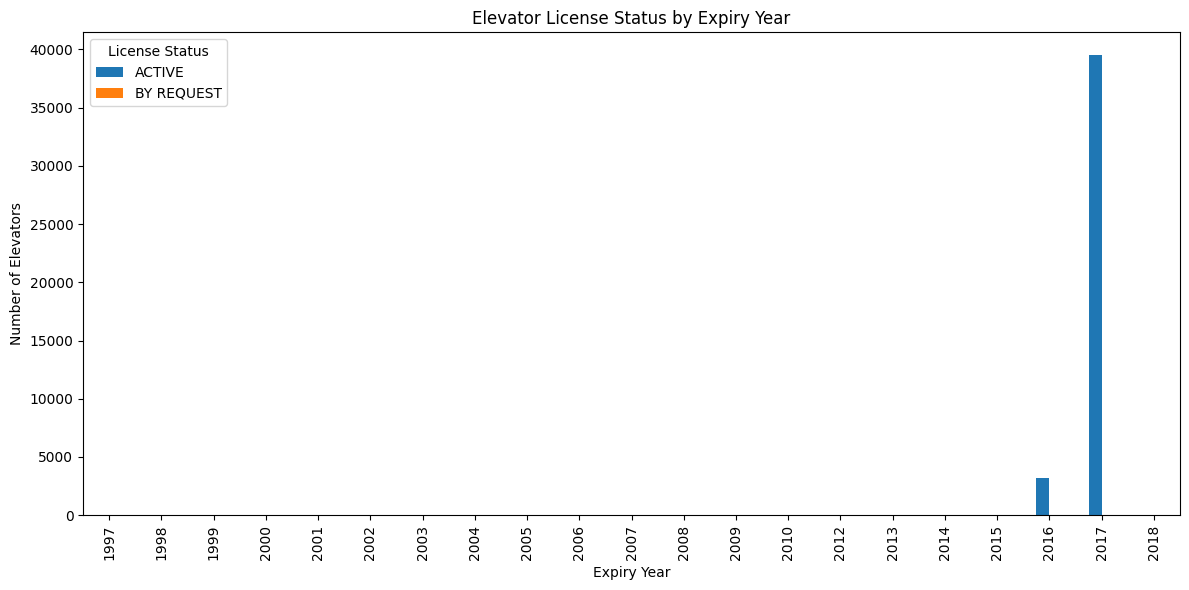

In [24]:
status_year = (
    df_filtered
    .groupby(["LICENSESTATUS", "ExpiryYear"])
    .size()
    .unstack(level=0, fill_value=0)
)

status_year.plot(kind="bar", figsize=(12, 6))
plt.title("Elevator License Status by Expiry Year")
plt.xlabel("Expiry Year")
plt.ylabel("Number of Elevators")
plt.legend(title="License Status")
plt.tight_layout()
plt.show()

The two-column chart reveals that ACTIVE and BY REQUEST licenses do not share the same expiry year distribution: ACTIVE licenses are spread across a broad range of years while BY REQUEST licenses are concentrated in a narrower band of earlier expiry periods, indicating that records pending administrative resolution skew toward older license dates. This temporal asymmetry was invisible in the single-column LICENSESTATUS chart, which showed only the aggregate count per status (approximately 42,665 ACTIVE vs 337 BY REQUEST) with no indication of when those licenses were scheduled to expire. Likewise, the single-column expiry-year chart showed the overall volume of expirations per year but could not distinguish whether a given year's expirations belonged to administratively current records or records still pending resolution. The combined view therefore identifies that BY REQUEST status is disproportionately associated with older license periods rather than being randomly distributed across time, which has direct operational implications for prioritising licence renewal workflows by age cohort.